In [49]:
import os
import json
import skimage.io
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
fontprops = fm.FontProperties(size=14)

toppath = '/mpc/homes/fische_r/nanotom_data/2023_COELY_postmortem'
processing_dict_path = os.path.join(toppath, 'processing_data.json')
processing_dict = json.load(open(processing_dict_path,'r'))

In [47]:
def Butterworth_like_filter(im, wc, n, recover = 1):
    # wc filter value
    # roll off parameter
    im = np.float64(im)
    gain = 1/(1+(im**2/wc**2)**n)
    g0 = 1-recover
    gain = g0 + gain*recover
    im_filt = im*gain
    return im_filt


## D series
FAA3-50 + Nafion115 stuck together without extra treatment

In [2]:
series = 'D'
series_path = os.path.join(toppath, series+'_series')

### D 1 (100mA/cm2)

In [3]:
sample = '1'
sersample = series+'_'+sample
sample_path = os.path.join(series_path, sersample )
im0_path = os.path.join(sample_path, sersample+'_preop_registered.tif') 
im1_path = os.path.join(sample_path, sersample+'_postop_1_registered.tif')
im2_path = os.path.join(sample_path, sersample+'_postop_2_registered.tif')

In [4]:
im0 = skimage.io.imread(im0_path)

In [5]:
im1 = skimage.io.imread(im1_path)

In [6]:
im2 = skimage.io.imread(im2_path)

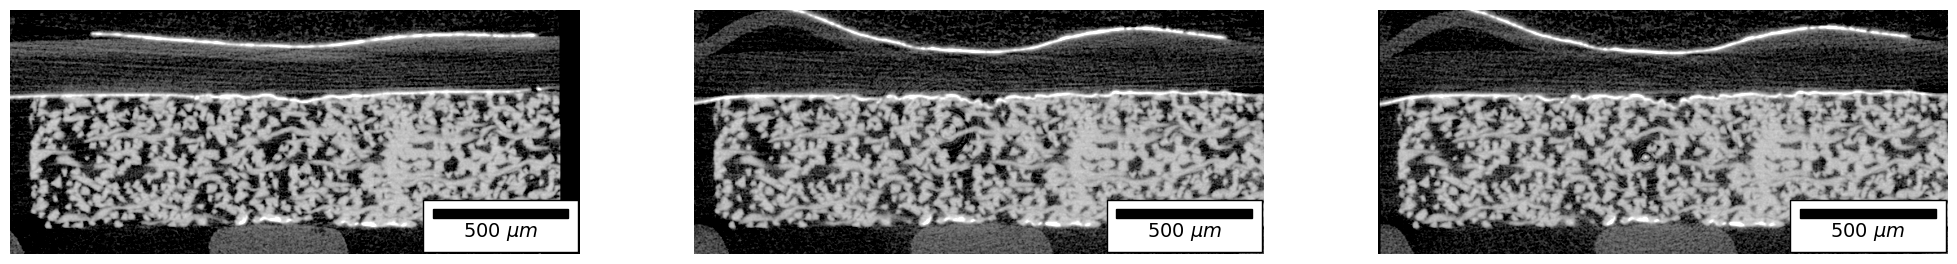

In [96]:
sn = 680 #slice number
vmin = -0.0673
vmax = 0.9670

vmin = 0.025
vmax = 0.9670/4

im0disp = im0[sn,:,:].transpose(1,0).copy()
im1disp = im1[sn,:,:].transpose(1,0).copy()
im2disp = im2[sn,:,:].transpose(1,0).copy()

# metal_th = 0.3
# im0disp[im0disp>metal_th] = im0disp[im0disp>metal_th]-metal_th*1.1
# im1disp[im1disp>metal_th] = im1disp[im1disp>metal_th]-metal_th*1.1
# im2disp[im2disp>metal_th] = im2disp[im2disp>metal_th]-metal_th*1.1

im0disp = Butterworth_like_filter(im0disp, 0.22, 1, 0.75)
im1disp = Butterworth_like_filter(im1disp,  0.22, 1, 0.75)
im2disp = Butterworth_like_filter(im2disp,  0.22, 1, 0.75)

fig, axs = plt.subplots(1,3, figsize = (25,5))
axs[0].imshow(im0disp, 'gray', vmin=vmin, vmax=vmax)
axs[1].imshow(im1disp, 'gray', vmin=vmin, vmax=vmax)
axs[2].imshow(im2disp, 'gray', vmin=vmin, vmax=vmax)

#display syle
for ax in axs:
    ax.axis('off')
    scalebar = AnchoredSizeBar(ax.transData,
                           500/3, '500 $\mu m$', 'lower right', 
                           pad=0.5,
                           color='black',
                           frameon=True,
                           size_vertical=10,
                           fontproperties=fontprops)
    ax.add_artist(scalebar)
# axs[0].add_artist(scalebar)
# axs[1].add_artist(scalebar)

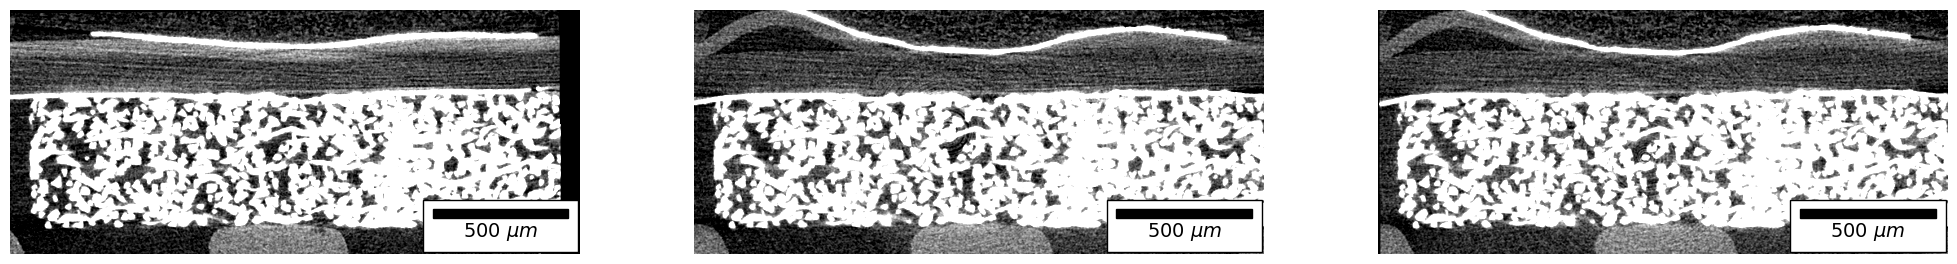

In [97]:
# sn = 676 #slice number
vmin = -0.0673
vmax = 0.9670

vmin = 0
vmax = 0.9670/4

im0disp = im0[sn,:,:].transpose(1,0).copy()
im1disp = im1[sn,:,:].transpose(1,0).copy()
im2disp = im2[sn,:,:].transpose(1,0).copy()

fig, axs = plt.subplots(1,3, figsize = (25,5))
axs[0].imshow(im0disp, 'gray', vmin=vmin, vmax=vmax)
axs[1].imshow(im1disp, 'gray', vmin=vmin, vmax=vmax)
axs[2].imshow(im2disp, 'gray', vmin=vmin, vmax=vmax)

#display syle
for ax in axs:
    ax.axis('off')
    scalebar = AnchoredSizeBar(ax.transData,
                           500/3, '500 $\mu m$', 'lower right', 
                           pad=0.5,
                           color='black',
                           frameon=True,
                           size_vertical=10,
                           fontproperties=fontprops)
    ax.add_artist(scalebar)
# axs[0].add_artist(scalebar)
# axs[1].add_artist(scalebar)

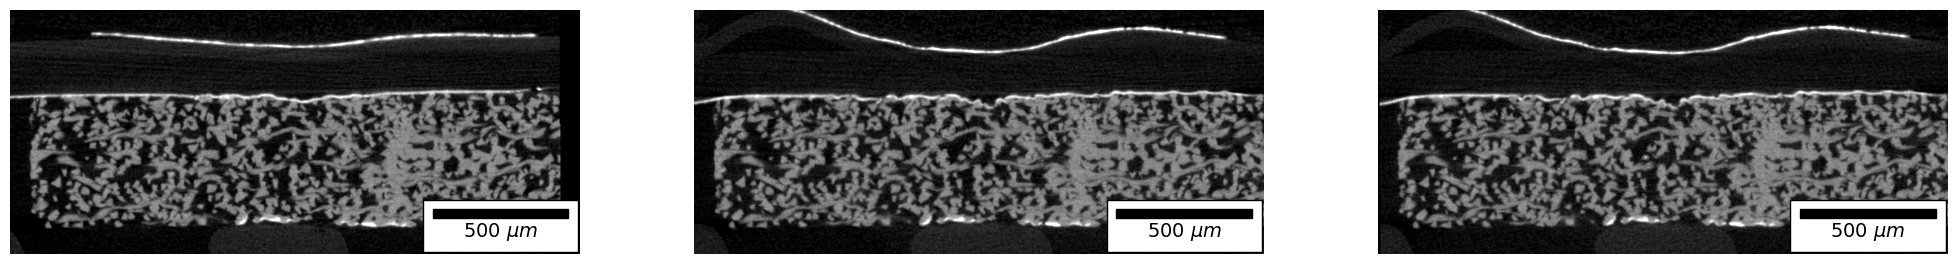

In [98]:
# sn = 676 #slice number
vmin = -0.0673
vmax = 0.9670

vmin = 0
vmax = 0.9670

im0disp = im0[sn,:,:].transpose(1,0).copy()
im1disp = im1[sn,:,:].transpose(1,0).copy()
im2disp = im2[sn,:,:].transpose(1,0).copy()

fig, axs = plt.subplots(1,3, figsize = (25,5))
axs[0].imshow(im0disp, 'gray', vmin=vmin, vmax=vmax)
axs[1].imshow(im1disp, 'gray', vmin=vmin, vmax=vmax)
axs[2].imshow(im2disp, 'gray', vmin=vmin, vmax=vmax)

#display syle
for ax in axs:
    ax.axis('off')
    scalebar = AnchoredSizeBar(ax.transData,
                           500/3, '500 $\mu m$', 'lower right', 
                           pad=0.5,
                           color='black',
                           frameon=True,
                           size_vertical=10,
                           fontproperties=fontprops)
    ax.add_artist(scalebar)
# axs[0].add_artist(scalebar)
# axs[1].add_artist(scalebar)